In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import transforms as T

transform = T.Compose(
    [
        T.Resize((256, 256)),
        T.ToTensor()
    ]
)

target_transform = T.Compose(
    [
        T.Resize((256, 256)),
        T.PILToTensor(),
        T.Lambda(lambda x: (x-1).long())
    ]
)

train_dataset = OxfordIIITPet('/datasets', download = True, transform = transform, target_transform = target_transform, target_types = 'segmentation')


100%|██████████| 792M/792M [00:29<00:00, 26.8MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.3MB/s]


In [3]:
from torch.utils.data import DataLoader
from torch.utils.data import Subset

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, num_workers = 4, pin_memory = True)


In [4]:
from torch import nn

def conv_plus_conv(in_channels: int, out_channels: int):
    return nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size = 3,
            padding = 1,
            stride = 1
        ),
        nn.BatchNorm2d(
            num_features = out_channels
        ),
        nn.LeakyReLU(0.2),
        nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size = 3,
            padding = 1,
            stride = 1
        ),
        nn.BatchNorm2d(
            num_features = out_channels
        ),
        nn.LeakyReLU(0.2),
    )

class UNET(nn.Module):

    def __init__(self):

        super().__init__()

        base_channels = 32

        self.down1 = conv_plus_conv(3, base_channels)
        self.down2 = conv_plus_conv(base_channels, base_channels*2)
        self.down3 = conv_plus_conv(base_channels*2, base_channels*4)
        self.down4 = conv_plus_conv(base_channels*4, base_channels*8)
        self.down5 = conv_plus_conv(base_channels*8, base_channels*16)

        self.up1 = conv_plus_conv(base_channels * 2, base_channels)
        self.up2 = conv_plus_conv(base_channels * 4, base_channels)
        self.up3 = conv_plus_conv(base_channels * 8, base_channels * 2)
        self.up4 = conv_plus_conv(base_channels * 16, base_channels * 4)
        self.up5 = conv_plus_conv(base_channels * 32, base_channels * 8)

        self.bottleneck = conv_plus_conv(base_channels * 16, base_channels * 16)

        self.out = nn.Conv2d(in_channels = base_channels, out_channels = 3, kernel_size = 1)
        self.downsample = nn.MaxPool2d(kernel_size = 2, stride = 2)

    def forward(self, x):

        residual1 = self.down1(x)
        x = self.downsample(residual1)

        residual2 = self.down2(x)
        x = self.downsample(residual2)
        
        residual3 = self.down3(x)
        x = self.downsample(residual3)
        
        residual4 = self.down4(x)
        x = self.downsample(residual4)
        
        residual5 = self.down5(x)
        x = self.downsample(residual5)

        x = self.bottleneck(x)

        x = nn.functional.interpolate(x, scale_factor = 2)
        x = torch.cat((x, residual5), dim = 1)
        x = self.up5(x)
        
        x = nn.functional.interpolate(x, scale_factor = 2)
        x = torch.cat((x, residual4), dim = 1)
        x = self.up4(x)
        
        x = nn.functional.interpolate(x, scale_factor = 2)
        x = torch.cat((x, residual3), dim = 1)
        x = self.up3(x)
        
        x = nn.functional.interpolate(x, scale_factor = 2)
        x = torch.cat((x, residual2), dim = 1)
        x = self.up2(x)
        
        x = nn.functional.interpolate(x, scale_factor = 2)
        x = torch.cat((x, residual1), dim = 1)
        x = self.up1(x)

        x = self.out(x)

        return x

In [5]:
from tqdm import tqdm
from torch.optim import Optimizer
def train(model: nn.Module, 
          loader: DataLoader, 
          optimizer: Optimizer, 
          loss_fn, 
          device: torch.device
         ):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for x, y in tqdm(loader, desc = 'Train'):
        bs = y.size(0)

        x, y = x.to(device), y.squeeze(1).to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = loss_fn(output.reshape(bs, 3, -1), y.reshape(bs, -1))
        train_loss += loss.item()
        loss.backward()
        optimizer.step()

        _, y_pred = output.max(dim = 1)
        total += y.size(0) * y.size(1) * y.size(2)
        correct += (y == y_pred).sum().item()
    train_loss /= len(loader)
    train_accuracy = correct / total
    return train_loss, train_accuracy

In [6]:
@torch.inference_mode()
def evaluate(model: nn.Module,
             loader: DataLoader,
             loss_fn,
             device: torch.device
            ):
    model.eval()

    total_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(loader, desc = 'Evaluate'):
        bs = y.size(0)
        x, y = x.to(device), y.squeeze(1).to(device)
        output = model(x)
        loss = loss_fn(output.reshape(bs, 3, -1), y.reshape(bs, -1))
        total_loss += loss.item()

        _, y_pred = output.max(dim = 1)
        total += y.size(0) * y.size(1) * y.size(2)
        correct += (y_pred == y).sum().item()

    total_loss /= len(loader)
    accuracy = correct / total
    return total_loss, accuracy

In [7]:

def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')
    
    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()
    plt.grid()

    plt.show()

In [8]:
@torch.inference_mode()
def predict_segmentation(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device
):
    model.eval()

    prediction = []

    for x, _ in tqdm(loader):
        output = model(x.to(device)).cpu()

        prediction.append(torch.argmax(output, dim = 1))
    prediction = torch.cat(prediction)
    return prediction

In [11]:
from IPython.display import clear_output
def whole_train_value_cycle(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    optimizer: Optimizer,
    loss_fn,
    device: torch.device,
    threshold: float,
    title: str
):
    train_loss_history = []
    valid_loss_history = []
    train_accuracy_history = []
    valid_accuracy_history = []

    for epoch in range(100):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history,
            valid_loss_history,
            train_accuracy_history,
            valid_accuracy_history,
            title
        )

        if valid_accuracy >= threshold:
            break
        

In [14]:
def set_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

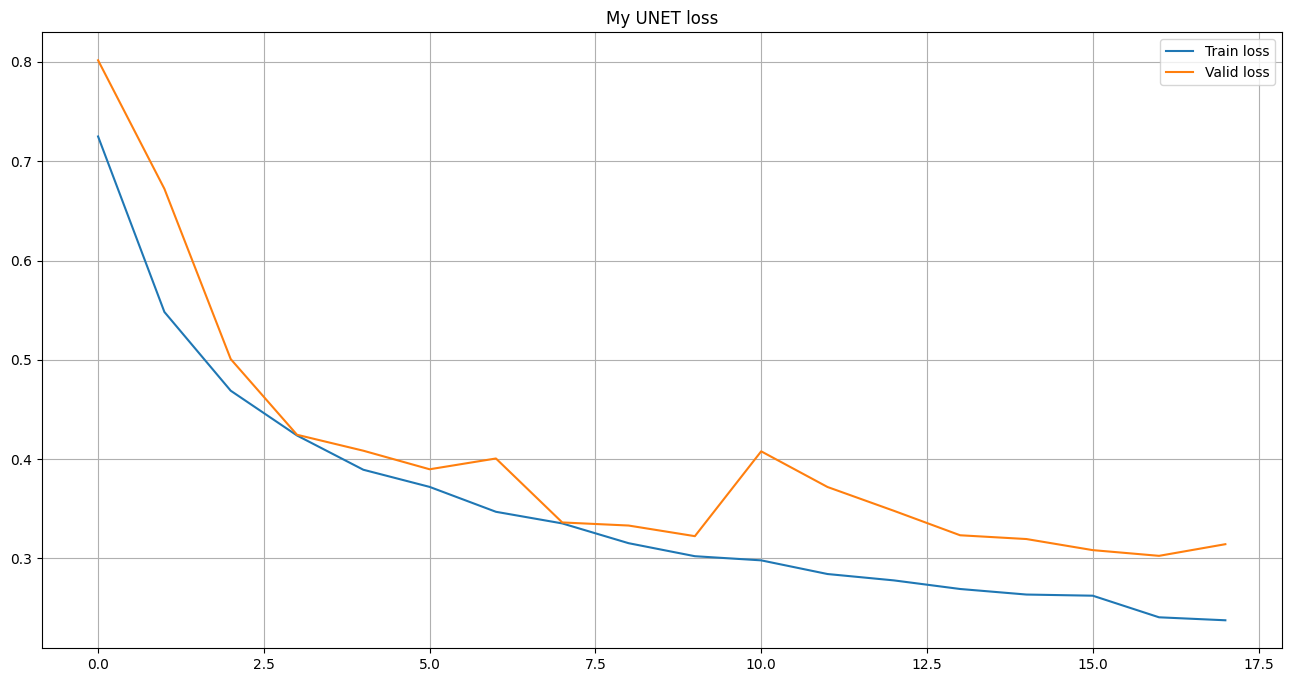

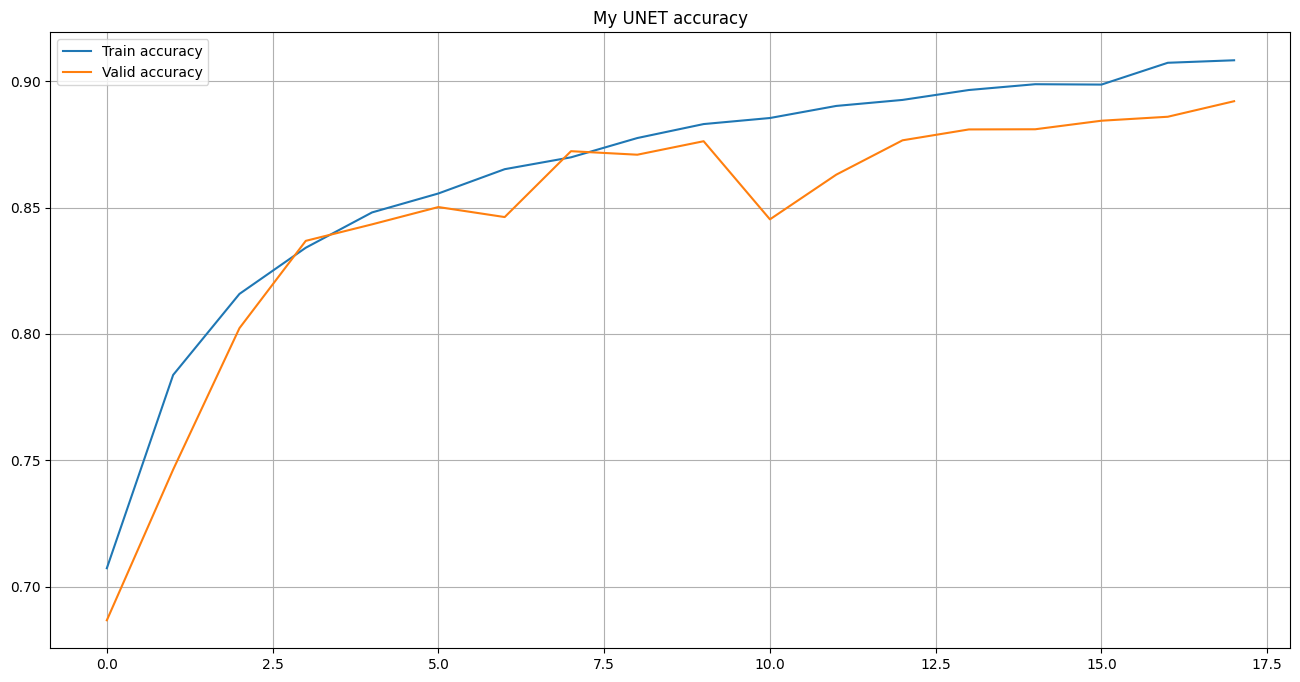

In [17]:
from torch.optim import Adam
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = UNET().to(device)
optimizer = Adam(model.parameters(), lr = 1e-3)
loss_fn = nn.CrossEntropyLoss()

valid_dataset = OxfordIIITPet('/datasets', download = True, split = 'test', transform = transform, target_transform = target_transform, target_types = 'segmentation')
np.random.seed(100)
idx = np.random.randint(len(valid_dataset), size=200).tolist()

valid_dataset = Subset(valid_dataset, idx)
valid_loader = DataLoader(valid_dataset, batch_size = 64, shuffle = False, num_workers = 4, pin_memory = True)

whole_train_value_cycle(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    device,
    0.89,
    'My UNET'
)

In [19]:
torch.save(predict_segmentation(model, valid_loader, device).reshape([200, 1, 256, 256]).to(torch.uint8), 'my_prediction_1.pt')

100%|██████████| 4/4 [00:04<00:00,  1.07s/it]
